In [17]:
import pennylane as qml
from opt_homo import optimizeHomo, optimize1q, optimize2q, singleCommutation
from opt_joint_ego import optimizeJointEgo
from opt_joint_long import *
from opt_swap import *
from qco_simple import *
from compare_sdk import *
from common_functions import *
from opt_joint_short import optimizeJointShort, optimizeJointShort_loop
from opt_cnot_long import *
import random
import gymnasium as gym
import numpy as np
import pennylane as qml
from stable_baselines3 import PPO

In [2]:
[ds] = qml.data.load("ketgpt")

In [ ]:
dataset = []
for s in range(1):
    seed = s
    @qml.qnode(qml.device('default.qubit'))
    def circuit():
        for op in ds.circuits[seed]:
            name = op.name
            params = op.parameters
            wires = op.wires
            if name == 'QubitUnitary':
                continue
            elif name == 'CZ':
                qml.Hadamard(wires[1])
                qml.CNOT(wires)
                qml.Hadamard(wires[1])
            elif name == 'U1':
                qml.RZ(params[0], wires=wires)
            elif name == 'U2':
                qml.RZ(params[0], wires=wires)
                qml.RY(np.pi/2, wires=wires)
                qml.RZ(params[1], wires=wires)
            else:
                qml.apply(op)
        return qml.state()
    circuit_info = extract_info_from_qnode(circuit)
    for opt in [optimizeHomo, optimizeJointEgo, cnotSwap]: # fixed initial routines
        circuit_info = opt(circuit_info)
    dataset.append(circuit_info)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 10       |
|    ep_rew_mean     | -260     |
| time/              |          |
|    fps             | 847      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------


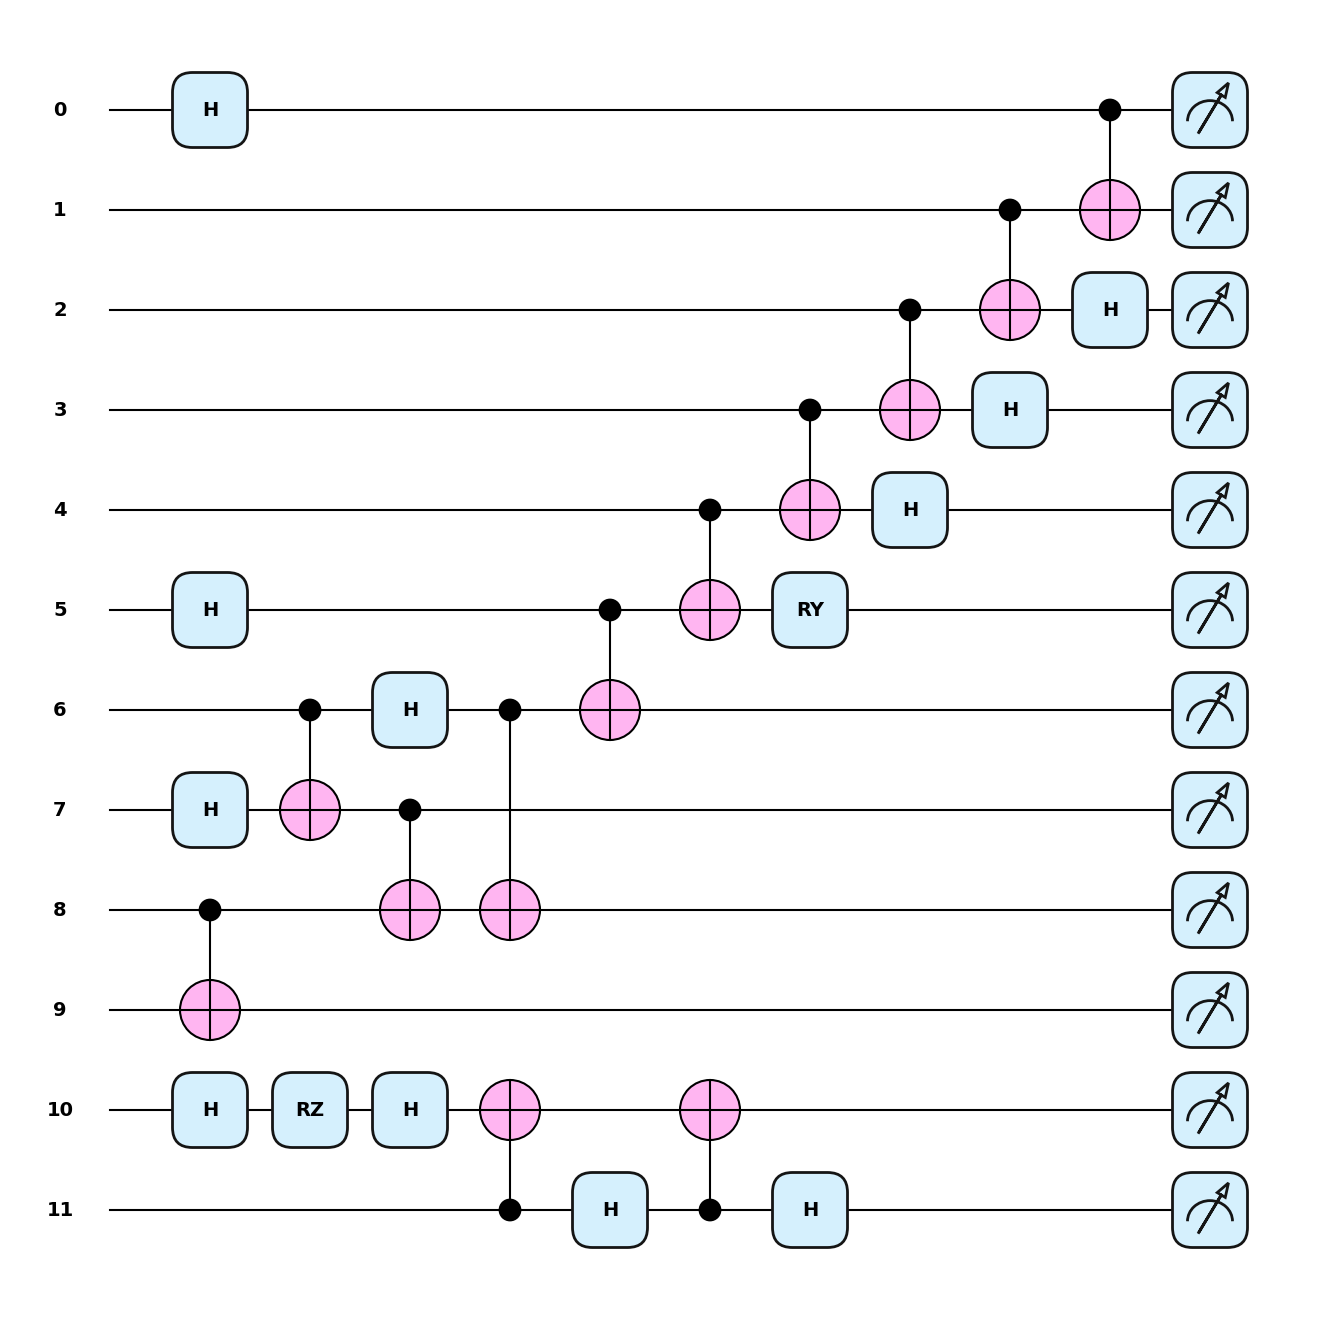

Initial gate count: 31
Best optimized gate count: 25


In [ ]:
class KetGPTEnv(gym.Env):
    def __init__(self, circuit, opt_functions, max_steps, patience):
        super().__init__()
        self.circuit = circuit
        self.opt_functions = opt_functions
        self.action_space = gym.spaces.Discrete(len(self.opt_functions))
        self.observation_space = gym.spaces.Box(low=0, high=100, shape=(1,), dtype=np.float32)
        self.max_steps = max_steps
        self.patience = patience
        self.current_step = 0
        self.no_change_counter = 0  
        self.best_circuit = circuit[:]
        self.best_count = len(circuit)

    def reset(self, *, seed=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.no_change_counter = 0
        obs = np.array([len(self.circuit)], dtype=np.float32)
        self.best_circuit = self.circuit[:]
        self.best_count = len(self.circuit)
        info = {}
        return obs, info

    def step(self, action):
        chosen_func = self.opt_functions[action]
        prev_count = len(self.circuit)
        self.circuit = chosen_func(self.circuit)
        curr_count = len(self.circuit)
        reward = -curr_count
        obs = np.array([curr_count], dtype=np.float32)

        self.current_step += 1
        terminated = False
        truncated = False

        if curr_count < self.best_count:
            self.best_count = curr_count
            self.best_circuit = self.circuit[:]

        if curr_count == prev_count: # Track no-change streak
            self.no_change_counter += 1
            reward -= 1  # penalty for useless action
        else:
            self.no_change_counter = 0  # reset if improvement happens

        if self.no_change_counter >= self.patience:
            terminated = True

        # Stop if max steps reached
        if self.current_step >= self.max_steps:
            truncated = True

        info = {"best_circuit": self.best_circuit, "best_count": self.best_count}
        return obs, reward, terminated, truncated, info
    
# train PPO
opt_functions = [
    optimize1q, optimize2q, optimizeJointEgo, optimizeJointShort, optimizeJointLong,
    singleCommutation, cnotSwap, optimizeForwardSwap, optimizeBackwwardSwap,
]
env = KetGPTEnv(circuit=dataset[0], opt_functions=opt_functions, 
                max_steps=40, patience=10)
model = PPO("MlpPolicy", env, verbose=1, device="cpu")
model.learn(total_timesteps=1000)

# evaluate PPO and get results
obs, info = env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

# post routine
circuit_info = info["best_circuit"]
circuit_info = push_long_cnot(phase_removal(circuit_info))
show_info(circuit_info)

# performance review
print("Initial gate count:", len(dataset[0]))
print("Best optimized gate count:", len(circuit_info))